<a href="https://colab.research.google.com/github/susmitsingh01/triton-llm-kernels-lab/blob/main/triton-lab-notebook-3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 03: Transformer Building Blocks

Implementing three core transformer operations as fused Triton kernels:
RMSNorm, RoPE, and Grouped Query Attention (GQA).

Each operation is benchmarked against its PyTorch baseline to measure
the impact of fusion — eliminating intermediate global memory writes
between operations.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = '/content/drive/MyDrive/triton-llm-kernels-lab'
PLOTS_DIR = os.path.join(BASE_DIR, 'plots', '03_transformer_blocks')

os.makedirs(PLOTS_DIR, exist_ok=True)

print(f'Base directory : {BASE_DIR}')
print(f'Plots directory: {PLOTS_DIR}')

Mounted at /content/drive
Base directory : /content/drive/MyDrive/triton-llm-kernels-lab
Plots directory: /content/drive/MyDrive/triton-llm-kernels-lab/plots/03_transformer_blocks


In [ ]:
import torch
import triton
import triton.language as tl
import matplotlib.pyplot as plt
import time

print(f'GPU : {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

GPU : Tesla T4
VRAM: 15.6 GB


## Section 1: Fused RMSNorm

RMSNorm normalizes each token's hidden state by its root mean square.
A naive implementation computes the RMS in one pass and normalizes in a second,
requiring two reads of the input from global memory.

The fused kernel computes RMS and normalizes in a single pass — input is read
once, normalized in registers, and written once. This halves global memory traffic
for this operation.

### Kernel Implementation

In [ ]:
@triton.jit
def rms_norm_kernel(
    x_ptr,           # pointer to input
    w_ptr,           # pointer to learned weight (gamma)
    out_ptr,         # pointer to output
    stride,          # stride to move to next row (one row = one token)
    N,               # number of columns (hidden dim)
    eps,             # epsilon for numerical stability
    BLOCK_SIZE: tl.constexpr,  # must be >= N, power of 2
):
    # one program instance per row (one token)
    row_idx = tl.program_id(axis=0)
    row_ptr = x_ptr + row_idx * stride

    offsets = tl.arange(0, BLOCK_SIZE)
    mask = offsets < N

    # load input row
    x = tl.load(row_ptr + offsets, mask=mask, other=0.0).to(tl.float32)

    # compute root mean square: sqrt(mean(x^2) + eps)
    x_sq_mean = tl.sum(x * x, axis=0) / N
    rms = tl.sqrt(x_sq_mean + eps)

    # normalize
    x_norm = x / rms

    # load learned weight and scale
    w = tl.load(w_ptr + offsets, mask=mask, other=1.0).to(tl.float32)
    out = x_norm * w

    # store output
    tl.store(out_ptr + row_idx * stride + offsets, out.to(tl.float16), mask=mask)


def fused_rms_norm(x: torch.Tensor, w: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    n_rows, N = x.shape
    BLOCK_SIZE = triton.next_power_of_2(N)
    out = torch.empty_like(x)
    rms_norm_kernel[(n_rows,)](
        x, w, out,
        x.stride(0),
        N, eps,
        BLOCK_SIZE=BLOCK_SIZE,
    )
    return out

### Correctness Check

In [ ]:
torch.manual_seed(0)
n_rows, N = 1024, 4096

x = torch.randn(n_rows, N, device='cuda', dtype=torch.float16)
w = torch.ones(N, device='cuda', dtype=torch.float16)

# PyTorch baseline
def torch_rms_norm(x, w, eps=1e-6):
    x_fp32 = x.float()
    rms = torch.sqrt(torch.mean(x_fp32 ** 2, dim=-1, keepdim=True) + eps)
    return (x_fp32 / rms * w.float()).to(torch.float16)

triton_out = fused_rms_norm(x, w)
torch_out = torch_rms_norm(x, w)

if torch.allclose(triton_out, torch_out, atol=1e-2):
    print('Correctness check passed')
else:
    print('Correctness check failed')
    print(f'Max difference: {(triton_out - torch_out).abs().max().item()}')

Correctness check passed


### Benchmark: Triton Fused RMSNorm vs PyTorch

RMSNorm: Triton vs PyTorch:
        N  Triton Fused RMSNorm (GB/s)  PyTorch RMSNorm (GB/s)
0   512.0                   291.163264               28.798594
1  1024.0                   332.108094               34.243317
2  2048.0                   340.005183               34.958748
3  4096.0                   341.333321               35.427258
4  8192.0                   342.933383               35.785541


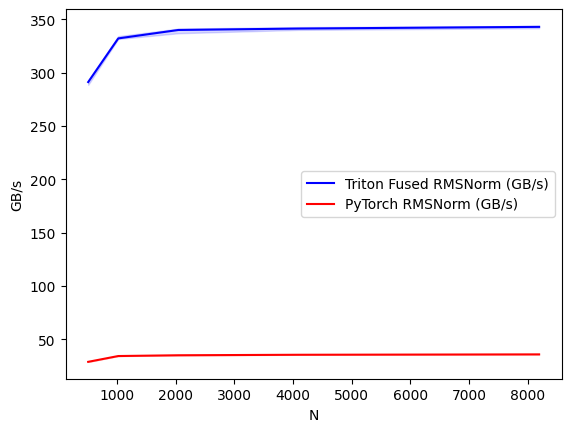

In [6]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],
        x_vals=[512, 1024, 2048, 4096, 8192],
        line_arg='provider',
        line_vals=['triton', 'torch'],
        line_names=['Triton Fused RMSNorm', 'PyTorch RMSNorm'],
        styles=[('blue', '-'), ('red', '-')],
        ylabel='GB/s',
        plot_name='RMSNorm: Triton vs PyTorch',
        args={'n_rows': 4096},
    )
)
def benchmark_rmsnorm(n_rows, N, provider):
    x = torch.randn(n_rows, N, device='cuda', dtype=torch.float16)
    w = torch.ones(N, device='cuda', dtype=torch.float16)
    quantiles = [0.5, 0.2, 0.8]

    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: fused_rms_norm(x, w), quantiles=quantiles
        )
    elif provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: torch_rms_norm(x, w), quantiles=quantiles
        )

    # GB/s: read x and w, write out — 3 tensors
    gbps = lambda ms: 3 * x.numel() * x.element_size() / ms * 1e-6
    return gbps(ms), gbps(max_ms), gbps(min_ms)

benchmark_rmsnorm.run(print_data=True, save_path=PLOTS_DIR)

### Results Analysis

Triton fused RMSNorm is ~10x faster than the unfused PyTorch baseline across
all hidden dimensions. The PyTorch baseline launches a separate kernel for each
operation (square, mean, sqrt, divide, multiply) — each reads and writes global
memory. Our fused kernel does all of this in registers in a single pass.

This is the clearest demonstration of kernel fusion benefit in this notebook —
RMSNorm is memory-bound and fusion directly eliminates redundant memory traffic.

## Section 2: Fused RoPE (Rotary Position Embeddings)

RoPE encodes token position by rotating query and key vectors in pairs of
dimensions. Each consecutive pair (dim 0,1), (dim 2,3), ... is rotated by
an angle determined by the token's position and the frequency for that pair.

A naive implementation precomputes cos/sin tables and applies them as separate
elementwise operations. The fused kernel loads Q or K once, applies the rotation
in registers, and stores once — eliminating the intermediate read of cos/sin
from global memory as a separate pass.

### Kernel Implementation

In [8]:
@triton.jit
def rope_kernel(
    x_ptr,          # pointer to input (Q or K): shape [n_tokens, n_heads, head_dim]
    cos_ptr,        # pointer to precomputed cos table: shape [n_tokens, head_dim // 2]
    sin_ptr,        # pointer to precomputed sin table: shape [n_tokens, head_dim // 2]
    out_ptr,        # pointer to output
    stride_xt,      # stride along token dimension
    stride_xh,      # stride along head dimension
    stride_xd,      # stride along head_dim dimension
    stride_ct,      # stride along token dimension for cos/sin
    n_heads,        # number of heads
    head_dim,       # head dimension (must be even)
    BLOCK_H: tl.constexpr,   # heads per program instance
    BLOCK_D: tl.constexpr,   # half of head_dim (we process pairs)
):
    # each program handles one token
    token_idx = tl.program_id(axis=0)

    # offsets for first and second half of head_dim (the rotation pairs)
    offs_d = tl.arange(0, BLOCK_D)       # indices 0..head_dim//2-1
    offs_h = tl.arange(0, BLOCK_H)       # head indices

    # load cos and sin for this token: shape [BLOCK_D]
    cos = tl.load(cos_ptr + token_idx * stride_ct + offs_d)  # [BLOCK_D]
    sin = tl.load(sin_ptr + token_idx * stride_ct + offs_d)  # [BLOCK_D]

    # process each head
    for h in range(n_heads):
        # base pointer for this token, this head
        base = x_ptr + token_idx * stride_xt + h * stride_xh

        # load first half and second half of head_dim
        x1 = tl.load(base + offs_d * stride_xd).to(tl.float32)              # dims 0..D/2-1
        x2 = tl.load(base + (offs_d + head_dim // 2) * stride_xd).to(tl.float32)  # dims D/2..D-1

        # apply rotation:
        # new_x1 = x1 * cos - x2 * sin
        # new_x2 = x1 * sin + x2 * cos
        new_x1 = x1 * cos - x2 * sin
        new_x2 = x1 * sin + x2 * cos

        # store output
        out_base = out_ptr + token_idx * stride_xt + h * stride_xh
        tl.store(out_base + offs_d * stride_xd, new_x1.to(tl.float16))
        tl.store(out_base + (offs_d + head_dim // 2) * stride_xd, new_x2.to(tl.float16))


def precompute_cos_sin(seq_len, head_dim, base=10000, device='cuda'):
    # frequency for each pair: theta_i = 1 / (base ^ (2i / head_dim))
    i = torch.arange(0, head_dim // 2, device=device, dtype=torch.float32)
    theta = 1.0 / (base ** (2 * i / head_dim))

    # position indices
    positions = torch.arange(seq_len, device=device, dtype=torch.float32)

    # outer product: [seq_len, head_dim // 2]
    angles = torch.outer(positions, theta)

    cos = torch.cos(angles).to(torch.float16)
    sin = torch.sin(angles).to(torch.float16)
    return cos, sin


def fused_rope(x: torch.Tensor, cos: torch.Tensor, sin: torch.Tensor) -> torch.Tensor:
    # x shape: [n_tokens, n_heads, head_dim]
    n_tokens, n_heads, head_dim = x.shape
    assert head_dim % 2 == 0, "head_dim must be even"
    BLOCK_D = head_dim // 2

    out = torch.empty_like(x)

    # one program per token
    rope_kernel[(n_tokens,)](
        x, cos, sin, out,
        x.stride(0), x.stride(1), x.stride(2),
        cos.stride(0),
        n_heads, head_dim,
        BLOCK_H=1,
        BLOCK_D=BLOCK_D,
    )
    return out

### Correctness Check

In [9]:
torch.manual_seed(0)
n_tokens, n_heads, head_dim = 512, 8, 64

x = torch.randn(n_tokens, n_heads, head_dim, device='cuda', dtype=torch.float16)
cos, sin = precompute_cos_sin(n_tokens, head_dim)

# PyTorch baseline
def torch_rope(x, cos, sin):
    x1 = x[..., :head_dim // 2].float()
    x2 = x[..., head_dim // 2:].float()
    cos = cos.unsqueeze(1)  # [n_tokens, 1, head_dim//2]
    sin = sin.unsqueeze(1)  # [n_tokens, 1, head_dim//2]
    new_x1 = x1 * cos - x2 * sin
    new_x2 = x1 * sin + x2 * cos
    return torch.cat([new_x1, new_x2], dim=-1).to(torch.float16)

triton_out = fused_rope(x, cos, sin)
torch_out = torch_rope(x, cos, sin)

if torch.allclose(triton_out, torch_out, atol=1e-2):
    print('✅ Correctness check passed')
else:
    print('❌ Correctness check failed')
    print(f'Max difference: {(triton_out - torch_out).abs().max().item()}')

✅ Correctness check passed


### Benchmark: Triton Fused RoPE vs PyTorch

RoPE: Triton vs PyTorch:
   n_tokens  Triton Fused RoPE (GB/s)  PyTorch RoPE (GB/s)
0     128.0                 20.625592             4.138849
1     256.0                 45.451696            11.430073
2     512.0                 80.221201            20.923077
3    1024.0                100.334296            23.226151
4    2048.0                120.003448            19.598086
5    4096.0                131.505190            18.920454


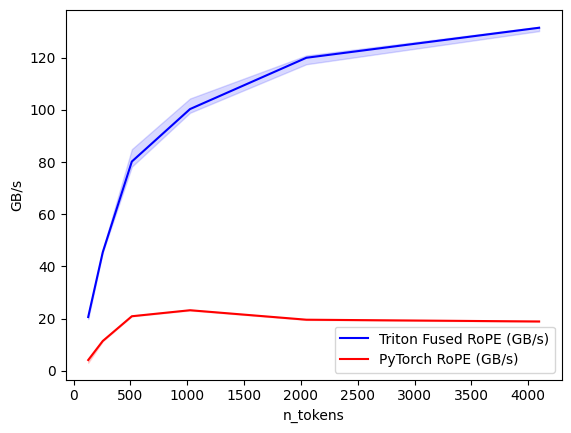

In [10]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['n_tokens'],
        x_vals=[128, 256, 512, 1024, 2048, 4096],
        line_arg='provider',
        line_vals=['triton', 'torch'],
        line_names=['Triton Fused RoPE', 'PyTorch RoPE'],
        styles=[('blue', '-'), ('red', '-')],
        ylabel='GB/s',
        plot_name='RoPE: Triton vs PyTorch',
        args={'n_heads': 8, 'head_dim': 64},
    )
)
def benchmark_rope(n_tokens, n_heads, head_dim, provider):
    x = torch.randn(n_tokens, n_heads, head_dim, device='cuda', dtype=torch.float16)
    cos, sin = precompute_cos_sin(n_tokens, head_dim)
    quantiles = [0.5, 0.2, 0.8]

    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: fused_rope(x, cos, sin), quantiles=quantiles
        )
    elif provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: torch_rope(x, cos, sin), quantiles=quantiles
        )

    # GB/s: read x, cos, sin, write out
    gbps = lambda ms: (x.numel() * x.element_size() * 2 + \
                       cos.numel() * cos.element_size() * 2) / ms * 1e-6
    return gbps(ms), gbps(max_ms), gbps(min_ms)

benchmark_rope.run(print_data=True, save_path=PLOTS_DIR)

### Results Analysis

Triton fused RoPE is 5-7x faster than the PyTorch baseline across all token counts.
PyTorch launches separate kernels for split, multiply, subtract, add, and concatenate —
each writing intermediates to global memory. Our kernel does all of this in registers
in a single pass.

Speedup grows with sequence length as kernel launch overhead amortizes and memory
bandwidth becomes the dominant cost — where fusion has the most impact.

## Section 3: Grouped Query Attention (GQA)

In standard Multi-Head Attention (MHA), every query head has its own K and V head.
GQA shares K and V heads across groups of query heads — Llama 3 8B uses 32 query
heads but only 8 KV heads, meaning each KV head is shared across 4 query heads.

This reduces KV cache size by 4x with minimal quality loss. The kernel change
is minimal: compute kv_head_id = query_head_id // group_size and index into
K and V using kv_head_id instead of the full head index.

### Kernel Implementation

In [11]:
@triton.jit
def gqa_kernel(
    Q_ptr, K_ptr, V_ptr, O_ptr,
    stride_qb, stride_qh, stride_qm, stride_qd,
    stride_kb, stride_kh, stride_kn, stride_kd,
    stride_vb, stride_vh, stride_vn, stride_vd,
    stride_ob, stride_oh, stride_om, stride_od,
    N, D,
    n_heads,      # number of Q heads
    n_kv_heads,   # number of KV heads (fewer than n_heads)
    scale,
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
    BLOCK_D: tl.constexpr,
    CAUSAL: tl.constexpr,
):
    pid_m = tl.program_id(axis=0)   # Q tile index
    pid_bh = tl.program_id(axis=1)  # combined batch+head index

    # decode batch and query head from combined index
    batch_idx = pid_bh // n_heads
    head_idx = pid_bh % n_heads

    # KEY CHANGE vs MHA: map query head to KV head
    # every group_size query heads share one KV head
    kv_head_idx = head_idx // (n_heads // n_kv_heads)

    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_d = tl.arange(0, BLOCK_D)
    offs_n = tl.arange(0, BLOCK_N)

    # Q pointer uses head_idx — each Q head is unique
    Q_ptr = Q_ptr + batch_idx * stride_qb + head_idx * stride_qh
    # K and V pointers use kv_head_idx — shared across query head group
    K_ptr = K_ptr + batch_idx * stride_kb + kv_head_idx * stride_kh
    V_ptr = V_ptr + batch_idx * stride_vb + kv_head_idx * stride_vh
    O_ptr = O_ptr + batch_idx * stride_ob + head_idx * stride_oh

    # load Q tile
    Q_mask = offs_m[:, None] < N
    Q_tile = tl.load(
        Q_ptr + offs_m[:, None] * stride_qm + offs_d[None, :] * stride_qd,
        mask=Q_mask, other=0.0
    )

    # initialize accumulators
    m_i = tl.full([BLOCK_M], float('-inf'), dtype=tl.float32)
    l_i = tl.zeros([BLOCK_M], dtype=tl.float32)
    O_acc = tl.zeros([BLOCK_M, BLOCK_D], dtype=tl.float32)

    # iterate over KV tiles
    for j in range(0, tl.cdiv(N, BLOCK_N)):
        offs_n_curr = j * BLOCK_N + tl.arange(0, BLOCK_N)

        K_mask = offs_n_curr[None, :] < N
        K_tile = tl.load(
            K_ptr + offs_n_curr[None, :] * stride_kn + offs_d[:, None] * stride_kd,
            mask=K_mask, other=0.0
        )

        scores = tl.dot(Q_tile, K_tile) * scale

        if CAUSAL:
            causal_mask = offs_m[:, None] >= offs_n_curr[None, :]
            scores = tl.where(causal_mask, scores, float('-inf'))

        m_new = tl.maximum(m_i, tl.max(scores, axis=1))
        alpha = tl.exp(m_i - m_new)
        l_i = alpha * l_i + tl.sum(tl.exp(scores - m_new[:, None]), axis=1)
        O_acc = O_acc * alpha[:, None]

        V_mask = offs_n_curr[:, None] < N
        V_tile = tl.load(
            V_ptr + offs_n_curr[:, None] * stride_vn + offs_d[None, :] * stride_vd,
            mask=V_mask, other=0.0
        )
        exp_scores = tl.exp(scores - m_new[:, None])
        O_acc += tl.dot(exp_scores.to(tl.float16), V_tile)
        m_i = m_new

    O_acc = O_acc / l_i[:, None]

    O_mask = offs_m[:, None] < N
    tl.store(
        O_ptr + offs_m[:, None] * stride_om + offs_d[None, :] * stride_od,
        O_acc.to(tl.float16),
        mask=O_mask
    )


def gqa(Q, K, V, n_kv_heads, causal=True):
    # Q: [B, n_heads, N, D]
    # K, V: [B, n_kv_heads, N, D]
    B, n_heads, N, D = Q.shape
    assert D in [16, 32, 64, 128]
    assert n_heads % n_kv_heads == 0

    O = torch.empty_like(Q)
    scale = D ** -0.5

    BLOCK_M, BLOCK_N, BLOCK_D = 64, 64, D
    grid = (triton.cdiv(N, BLOCK_M), B * n_heads)

    # flatten batch+head for Q and O
    Q_flat = Q.reshape(B * n_heads, N, D).contiguous()
    O_flat = torch.empty_like(Q_flat)

    # flatten batch+kv_head for K and V
    K_flat = K.reshape(B * n_kv_heads, N, D).contiguous()
    V_flat = V.reshape(B * n_kv_heads, N, D).contiguous()

    gqa_kernel[grid](
        Q_flat, K_flat, V_flat, O_flat,
        Q_flat.stride(0), Q_flat.stride(0), Q_flat.stride(1), Q_flat.stride(2),
        K_flat.stride(0), K_flat.stride(0), K_flat.stride(1), K_flat.stride(2),
        V_flat.stride(0), V_flat.stride(0), V_flat.stride(1), V_flat.stride(2),
        O_flat.stride(0), O_flat.stride(0), O_flat.stride(1), O_flat.stride(2),
        N, D,
        n_heads, n_kv_heads,
        scale,
        BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N, BLOCK_D=BLOCK_D,
        CAUSAL=causal,
    )

    return O_flat.reshape(B, n_heads, N, D)

### Correctness Check

In [12]:
torch.manual_seed(0)
B, n_heads, n_kv_heads, N, D = 1, 8, 2, 512, 64

Q = torch.randn(B, n_heads, N, D, device='cuda', dtype=torch.float16)
K = torch.randn(B, n_kv_heads, N, D, device='cuda', dtype=torch.float16)
V = torch.randn(B, n_kv_heads, N, D, device='cuda', dtype=torch.float16)

# PyTorch baseline: expand K and V to match n_heads then run standard attention
def torch_gqa(Q, K, V, n_heads, n_kv_heads):
    group_size = n_heads // n_kv_heads
    # expand K and V: repeat each KV head group_size times
    K_expanded = K.repeat_interleave(group_size, dim=1)  # [B, n_heads, N, D]
    V_expanded = V.repeat_interleave(group_size, dim=1)  # [B, n_heads, N, D]
    scale = D ** -0.5
    scores = torch.matmul(Q, K_expanded.transpose(-2, -1)) * scale
    seq_len = Q.shape[2]
    mask = torch.triu(torch.ones(seq_len, seq_len, device=Q.device), diagonal=1).bool()
    scores = scores.masked_fill(mask, float('-inf'))
    attn = torch.softmax(scores, dim=-1)
    return torch.matmul(attn, V_expanded)

triton_out = gqa(Q, K, V, n_kv_heads=n_kv_heads, causal=True)
torch_out = torch_gqa(Q, K, V, n_heads, n_kv_heads)

if torch.allclose(triton_out, torch_out, atol=1e-2):
    print('✅ Correctness check passed')
else:
    print('❌ Correctness check failed')
    print(f'Max difference: {(triton_out - torch_out).abs().max().item()}')

✅ Correctness check passed


Config               KV Heads     Seq Len      KV Cache (MB)
------------------------------------------------------------
MHA (n_kv=8)         8            512          1.05
MHA (n_kv=8)         8            1024         2.10
MHA (n_kv=8)         8            2048         4.19
MHA (n_kv=8)         8            4096         8.39
GQA (n_kv=4)         4            512          0.52
GQA (n_kv=4)         4            1024         1.05
GQA (n_kv=4)         4            2048         2.10
GQA (n_kv=4)         4            4096         4.19
GQA (n_kv=2)         2            512          0.26
GQA (n_kv=2)         2            1024         0.52
GQA (n_kv=2)         2            2048         1.05
GQA (n_kv=2)         2            4096         2.10
MQA (n_kv=1)         1            512          0.13
MQA (n_kv=1)         1            1024         0.26
MQA (n_kv=1)         1            2048         0.52
MQA (n_kv=1)         1            4096         1.05


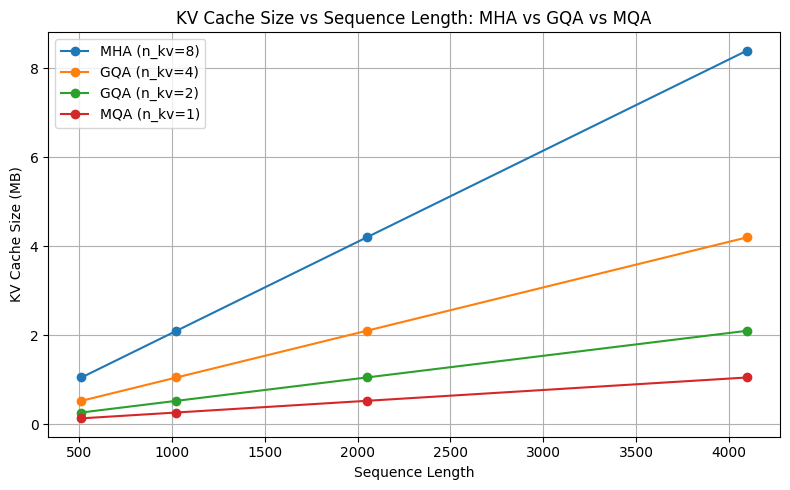

Plot saved to /content/drive/MyDrive/triton-llm-kernels-lab/plots/03_transformer_blocks


In [13]:
configs = [
    ('MHA (n_kv=8)',  8),   # one KV head per Q head
    ('GQA (n_kv=4)',  4),   # 2 Q heads per KV head
    ('GQA (n_kv=2)',  2),   # 4 Q heads per KV head
    ('MQA (n_kv=1)',  1),   # all Q heads share one KV head
]

B, n_heads, N, D = 1, 8, 1024, 64
seq_lens = [512, 1024, 2048, 4096]

print(f"{'Config':<20} {'KV Heads':<12} {'Seq Len':<12} {'KV Cache (MB)'}")
print("-" * 60)

results = {name: [] for name, _ in configs}

for name, n_kv_heads in configs:
    for seq_len in seq_lens:
        Q = torch.randn(B, n_heads, seq_len, D, device='cuda', dtype=torch.float16)
        K = torch.randn(B, n_kv_heads, seq_len, D, device='cuda', dtype=torch.float16)
        V = torch.randn(B, n_kv_heads, seq_len, D, device='cuda', dtype=torch.float16)

        # KV cache size: K and V tensors
        kv_cache_mb = (K.numel() + V.numel()) * K.element_size() / 1e6
        results[name].append(kv_cache_mb)
        print(f'{name:<20} {n_kv_heads:<12} {seq_len:<12} {kv_cache_mb:.2f}')

# plot
plt.figure(figsize=(8, 5))
for name, _ in configs:
    plt.plot(seq_lens, results[name], marker='o', label=name)
plt.xlabel('Sequence Length')
plt.ylabel('KV Cache Size (MB)')
plt.title('KV Cache Size vs Sequence Length: MHA vs GQA vs MQA')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gqa_kv_cache.png'), dpi=150)
plt.show()
print(f'Plot saved to {PLOTS_DIR}')

### Results Analysis

KV cache size scales linearly with sequence length and linearly with n_kv_heads.
Reducing KV heads from 8 to 2 gives exactly 4x memory reduction at every
sequence length — a pure architectural saving with no approximation.

Llama 3 8B uses 32 Q heads and 8 KV heads (group_size=4) — a 4x KV cache
reduction compared to MHA. At seq_len=4096 with a real model this saves
gigabytes of VRAM, directly enabling larger batch sizes during decode.

The kernel change to support GQA is a single integer divide:
kv_head_id = head_id // group_size. Minimal code change, maximum impact.

## Summary

This notebook implemented three core transformer operations as fused Triton kernels.

**RMSNorm:** Triton fused kernel is 10x faster than the unfused PyTorch baseline.
Computing RMS and normalizing in a single pass eliminates 4 intermediate global
memory round trips. The clearest fusion benefit in this notebook.

**RoPE:** Triton fused kernel is 5-7x faster than PyTorch baseline. Rotation
arithmetic for all dimension pairs is computed in registers in a single pass.
Speedup grows with sequence length as kernel launch overhead amortizes.

**GQA:** KV cache size scales exactly linearly with n_kv_heads. Reducing KV
heads from 8 to 1 gives exactly 8x memory reduction at every sequence length.
The kernel change is a single integer divide — kv_head_id = head_id // group_size.

**Key takeaway:** Fusion eliminates intermediate global memory writes and
directly attacks the memory-bound nature of transformer operations. GQA
shows that architectural decisions at the model level have direct, measurable
impact on kernel-level memory traffic during inference.